<a href="https://colab.research.google.com/github/AbhishekShah272002/Machine-Learning-Study./blob/main/Learning-Labs/mushroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [2]:
import pandas
from google.colab import files
uploaded = files.upload()


Saving mushroom secondary_data_csv.csv to mushroom secondary_data_csv.csv


In [3]:
df = pd.read_csv("mushroom secondary_data_csv.csv", sep=";")
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [4]:
X = df.drop("class", axis=1)
y = df["class"]

In [5]:
label_encoders={}

for column in X.columns:
  le= LabelEncoder()
  X[column]=le.fit_transform(X[column].astype(str))
  label_encoders[column]=le

In [6]:
target_encoder=LabelEncoder()
y=target_encoder.fit_transform(y.astype(str))

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples: ",X_train.shape[0])
print("Testing Samples: ",X_test.shape[0])

Training Samples:  48855
Testing Samples:  12214


In [8]:
model=CategoricalNB()
model.fit(X_train,y_train)

CategoricalNB()

In [9]:
y_pred=model.predict(X_test)

In [10]:
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy: ",accuracy)
print("Accuracy (%):",accuracy*100)

Accuracy:  0.7717373505813001
Accuracy (%): 77.17373505813


In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4122 1314]
 [1474 5304]]


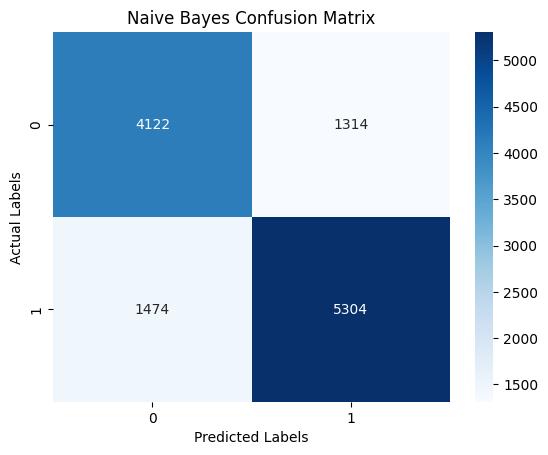

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [13]:
print(classification_report
      (
          y_test,
          y_pred,
          target_names=target_encoder.classes_
      ))

              precision    recall  f1-score   support

           e       0.74      0.76      0.75      5436
           p       0.80      0.78      0.79      6778

    accuracy                           0.77     12214
   macro avg       0.77      0.77      0.77     12214
weighted avg       0.77      0.77      0.77     12214

